# Task 10 - Comparing Three Segmentation Approaches
Image: `smarties.png`. Methods: global thresholding, HSV color thresholding, and K-Means.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('outputs')
OUT.mkdir(exist_ok=True)

In [2]:
bgr = cv2.imread("dog.jpeg")

if bgr is None:
    raise FileNotFoundError(
        "Place dog.jpeg in the notebook folder."
    )

# Convert the image from BGR to RGB for displaying with Matplotlib
rgb = cv2.cvtColor(
    bgr,
    cv2.COLOR_BGR2RGB
)


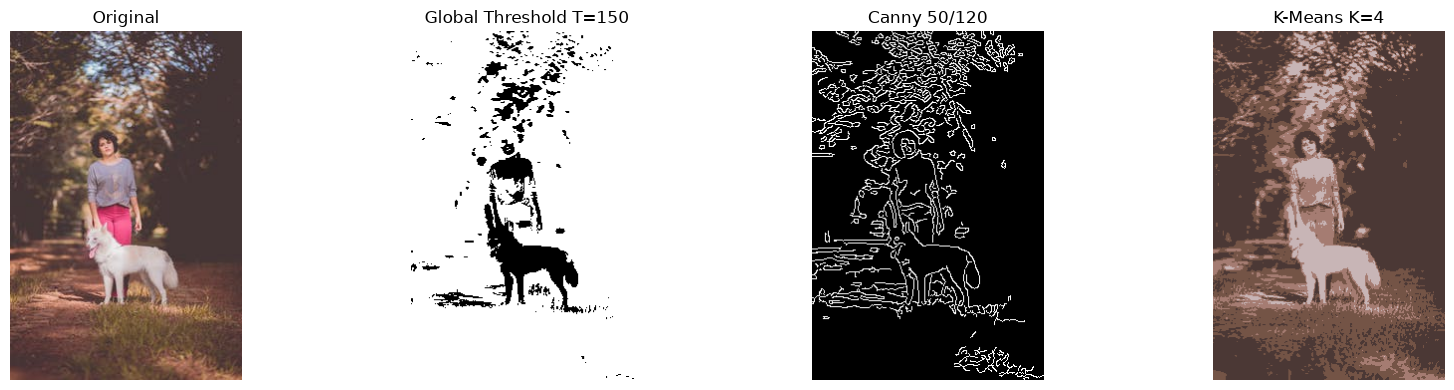

True

In [3]:
# ---------------------------------------------------------
# Global Thresholding
# ---------------------------------------------------------

# Convert the image to grayscale
gray = cv2.cvtColor(
    bgr,
    cv2.COLOR_BGR2GRAY
)

# Apply fixed global thresholding
_, global_mask = cv2.threshold(
    gray,
    150,
    255,
    cv2.THRESH_BINARY_INV
)


# ---------------------------------------------------------
# Canny Edge Segmentation
# ---------------------------------------------------------

# Apply a small blur to reduce noise before edge detection
blurred = cv2.GaussianBlur(
    gray,
    (5, 5),
    1.0
)

# Detect significant object and scene boundaries
canny_mask = cv2.Canny(
    blurred,
    50,
    120
)


# ---------------------------------------------------------
# K-Means Color Segmentation
# ---------------------------------------------------------

# Reshape RGB image into a list of pixels
data = np.float32(
    rgb.reshape(-1, 3)
)

# K-Means termination criteria
criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    100,
    0.2
)

# Reproducible K-Means result
cv2.setRNGSeed(42)

# Apply K-Means using four clusters
_, labels, centers = cv2.kmeans(
    data,
    4,
    None,
    criteria,
    10,
    cv2.KMEANS_PP_CENTERS
)

# Convert cluster colours to uint8
centers = np.uint8(centers)

# Reconstruct segmented image

km = centers[
    labels.flatten()
].reshape(rgb.shape)


# ---------------------------------------------------------
# Display Three Segmentation Approaches
# --------------------------------------------------------


fig, ax = plt.subplots(
    1,
    4,
    figsize=(17, 4)
)

# Prepare images and titles
items = [
    ("Original", rgb),
    ("Global Threshold T=150", global_mask),
    ("Canny 50/120", canny_mask),
    ("K-Means K=4", km)
]

# Display each result
for a, (title, image) in zip(ax, items):
    a.imshow(
        image,
        cmap="gray" if image.ndim == 2 else None
    )
    a.set_title(title)
    a.axis("off")

# Adjust spacing
plt.tight_layout()

# Display the comparison
plt.show()


# ---------------------------------------------------------
# Save the final K-Means result
# ---------------------------------------------------------

cv2.imwrite(
    str(OUT / "task10_final_kmeans.png"),
    cv2.cvtColor(
        km,
        cv2.COLOR_RGB2BGR
    )
)


## Technical comparison
**Global thresholding:** assumes the desired regions can be separated by grayscale intensity. It can isolate intensity-distinct areas, but differently colored Smarties with similar brightness may be confused. The threshold value has the greatest effect.

**HSV color thresholding:** assumes the target has a reasonably compact HSV color range. It directly identifies the yellow object(s), while lighting-induced color variation or similarly colored pixels can be missed/included. Hue/Saturation/Value bounds have the greatest effect.

**K-Means:** assumes pixels form a chosen number of compact color clusters. It simplifies the whole scene into representative color regions, but clusters are not guaranteed to correspond exactly to semantic objects. `K` has the greatest effect.

**Conclusion:** For the specific goal of isolating the yellow object, HSV thresholding is the most meaningful because color, rather than grayscale intensity alone, distinguishes the target. K-Means is more suitable when the goal is whole-image color simplification rather than selecting one known color.